__Processing & Analysis of $^{214}\text{Bi}$-MC Files__

__ESTE ES PARA VALIDAR NUESTRAS ACCIONES EN LOS OTROS NOTEBOOKS DE BI-MC__

Pau has produced MC samples of $^{214}\text{Bi}$ decays in different volumes of the detector.
<br>
We are interested in:
- How many electrons coming from the $^{214}\text{Bi}$ @ cathode end up being fiducials.
- Energy specturm of fiducial electrons induced by $^{214}\text{Bi}$.
<!-- end of the list -->
This notebook has the following four main parts:
- In _Preliminary_ you configure the type of analysis (_cathode_ or _all_) and its corresponding parameters for subsequent processing.
- There is a _Validation Zone_ where all the interesting actions in the processing are inspected in detail.
- All the processing of an entire set of MCs is applied in _Processing_.
- In _Analysis_, we apply $nS2 = 1$ cut and detector region tagging. Then, we define the input processed files for the _Spectrums_ (plotting purposes) and _ROI & Background Index_ analysis,
  <br>
  where we compute the important numbers such as rates, back. index, efficiencies.

__IMPORTANT__: Define in _Preliminary_ all the configuration needed for the use of this notebook.

In [2]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import bckg_functions as bf
from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

from datetime import datetime
import glob
from invisible_cities.reco.corrections import read_maps
from invisible_cities.reco.corrections import apply_all_correction
from invisible_cities.types.symbols    import NormStrategy
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import scipy

# Styling Plot
pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Preliminary

In [3]:
# ----- Date of Analysis ----- #
DATE = datetime.now().strftime('%d%m%Y')        # Current Date
# DATE = '01122025'                             # Specific Date

In [55]:
# --------------------------------------------
# 1. INPUT FILES & EXTRA INFORMATION
# --------------------------------------------
INPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Rn_analysis/h5/'
ALL_FILENAME  = 'processed_MC_background_All_' + DATE + '.h5'
CATH_FILENAME = 'processed_MC_background_Cathode_' + DATE + '.h5'

DETECTOR_ZONES = ['All', 'Cathode']

# ----- Simulated Exposure Time ----- #
RUN_TIME_ALL  = 315360000                   # 10 years in [s]
scale_factor = 1.17 / 0.82                  # If the actual simulated activity is different from original one
RUN_TIME_CATH = 315360 * scale_factor       # 0.01 year in [s]

# ----- Generated Events ----- #
# You can find these numbers in Bi_MC_Effs.txt
GEN_EVTS_ALL  = 2918945850
GEN_EVTS_CATH = 385000

# ------------------------
# 2. ANALYSIS PARAMETERS
# ------------------------
# --- Trigger 2 Efficiency ---
# Events with event-level energy below this are removed to account for trigger efficiency.
TRG2_THRESHOLD = 0.5         # in [MeV]

# ---- ROI definition ----
ROI_MIN = 2.4; ROI_MAX = 2.5    # in [MeV]

# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]


In [108]:
print(RUN_TIME_CATH)

449964.8780487805


#### Dictionary for event counts of interest

In [24]:
# Dictionary
Bi_MC_INFO = {
                'All': {
                                'gen_cv': GEN_EVTS_ALL,
                                'incl_cv': 0,  'incl_roi_cv': 0,
                                'fidu_cv': 0,  'fidu_roi_cv': 0
                        },

                'Cathode': {
                                'gen_cv': GEN_EVTS_CATH,
                                'incl_cv': 0,  'incl_roi_cv': 0,
                                'fidu_cv': 0,  'fidu_roi_cv': 0
                        }
}

Here you have your dataframes!

In [25]:
ALL_MC_EVT_DF = pd.read_hdf(os.path.join(INPUT_DIR, ALL_FILENAME), key='Events')
ALL_MC_EVT_DF

,event,time,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_mev,n_cluster,nS1,nS2,S1e,S1e_corr,isotope,volume,global_event,region
0,0,1.253990e+06,-344.062292,-165.221148,33.491546,15.618709,44.207833,438.390558,0.402713,1,1,2,154.0,301.240324,Bi214,ANODE_RING,0,anode
1,1,2.387403e+06,-126.622985,-96.187692,786.343249,20.197641,1122.937601,421.680941,0.439779,2,1,3,214.0,416.544628,Bi214,ANODE_RING,1,anode
2,2,4.019228e+06,-289.211259,-104.123245,94.026652,45.461306,172.613587,384.056033,1.228004,0,1,1,404.0,760.200979,Bi214,ANODE_RING,2,fiducial
3,4,8.671749e+06,54.690894,303.960486,224.723701,144.440472,270.774260,373.793521,0.611557,1,1,2,224.0,394.683128,Bi214,ANODE_RING,3,fiducial
4,6,1.259170e+07,-44.761349,-97.411481,258.288332,206.304826,307.595215,356.693883,0.567312,2,1,2,219.0,360.642406,Bi214,ANODE_RING,4,fiducial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938276,1079049162,2.158098e+15,10.500844,-77.494315,1068.066358,1027.056315,1092.366998,468.466361,0.606246,0,1,1,343.0,361.228568,Bi214,VESSEL,938276,tube
938277,1079049163,2.158098e+15,354.418014,225.414714,1163.723800,1138.192943,1196.814195,501.140880,0.862196,0,1,1,366.0,372.285740,Bi214,VESSEL,938277,cathode
938278,1079049164,2.158098e+15,-56.628661,-334.027075,143.636026,122.202824,159.503190,410.315106,0.690275,0,1,1,237.0,420.271670,Bi214,VESSEL,938278,fiducial
938279,1079049165,2.158098e+15,-60.273219,183.985071,208.540667,116.515335,345.904306,413.841831,0.905250,1,1,2,339.0,565.987428,Bi214,VESSEL,938279,fiducial


In [26]:
CATHODE_MC_EVT_DF = pd.read_hdf(os.path.join(INPUT_DIR, CATH_FILENAME), key='Events')
CATHODE_MC_EVT_DF

,event,time,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_mev,n_cluster,nS1,nS2,S1e,S1e_corr,isotope,volume,global_event,region
0,0,1.434202e+06,169.343029,4.040181,1048.267768,660.045456,1275.048836,511.922832,1.056133,3,1,4,343.0,437.000344,Bi214,CATHODE_SURF,0,cathode
1,1,2.309077e+06,-311.193402,256.576148,1151.741938,1133.088217,1188.223489,528.117758,0.488223,0,1,2,246.0,250.688353,Bi214,CATHODE_SURF,1,cathode
2,4,9.143824e+06,-389.348785,-251.846303,1220.717102,1156.417702,1294.694959,539.255604,0.936507,1,1,2,279.0,280.393556,Bi214,CATHODE_SURF,2,cathode
3,5,1.199260e+07,-427.131233,139.167993,1177.332623,1164.223125,1195.189253,506.334036,0.356754,0,1,2,162.0,163.164429,Bi214,CATHODE_SURF,3,cathode
4,6,1.368604e+07,-273.631751,-316.367478,1064.283783,1052.100026,1075.893765,473.768858,0.247048,0,1,2,128.0,135.265437,Bi214,CATHODE_SURF,4,tube
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275788,384974,7.699485e+11,210.045642,-162.657607,1182.972533,1170.394687,1197.573052,317.859483,0.279856,0,1,1,133.0,133.714388,Bi214,CATHODE_SURF,275788,cathode
275789,384975,7.699515e+11,157.697665,402.047164,1222.142934,1138.291361,1245.364436,578.582441,8.192628,1,1,1,277.0,273.325574,Bi214,CATHODE_SURF,275789,cathode
275790,384976,7.699524e+11,-283.033723,281.355039,1173.478481,1026.862305,1214.045198,572.328604,9.830983,1,1,2,846.0,846.540262,Bi214,CATHODE_SURF,275790,cathode
275791,384977,7.699542e+11,-240.705070,-377.714782,1183.229019,1169.617342,1193.452732,487.944276,0.167344,0,1,2,63.0,63.245754,Bi214,CATHODE_SURF,275791,cathode


# Analysis

## Trigger02 Efficiency: or inclusive sample

In [27]:
# List for updated dataframes
updated_dfs = []

for i, dataframe in enumerate([ALL_MC_EVT_DF, CATHODE_MC_EVT_DF]):
    
    trg2_mask = (dataframe['E_mev'] >= TRG2_THRESHOLD)
    events_after_trg2_ids = dataframe.loc[trg2_mask, 'global_event'].unique()
    incl_evts = len(events_after_trg2_ids)

    # Update Bi_MC_INFO dictionary
    label = DETECTOR_ZONES[i]
    Bi_MC_INFO[label]['incl_cv'] = incl_evts
    print(f"{label} MC [Energy ≥ {TRG2_THRESHOLD} MeV]: {incl_evts} events ({incl_evts/dataframe['global_event'].nunique():.2%})")

    # Update dataframe
    new_df = dataframe[dataframe['global_event'].isin(events_after_trg2_ids)].copy()
    updated_dfs.append(new_df)

ALL_MC_EVT_DF, CATHODE_MC_EVT_DF = updated_dfs

All MC [Energy ≥ 0.5 MeV]: 672414 events (71.66%)
Cathode MC [Energy ≥ 0.5 MeV]: 178023 events (64.55%)


Extract ROI information

In [35]:
for i, dataframe in enumerate([ALL_MC_EVT_DF, CATHODE_MC_EVT_DF]):
    
    roi_mask = (dataframe['E_mev'] >= ROI_MIN) & (dataframe['E_mev'] <= ROI_MAX)
    events_roi_ids = dataframe.loc[roi_mask, 'global_event'].unique()
    incl_evts_in_roi = len(events_roi_ids)

    # Update Bi_MC_INFO dictionary
    label = DETECTOR_ZONES[i]
    Bi_MC_INFO[label]['incl_roi_cv'] = incl_evts_in_roi
    print(f"{label} MC: {incl_evts_in_roi} inclusive events in ROI")

All MC: 250 inclusive events in ROI
Cathode MC: 398 inclusive events in ROI


## Fiducial Sample

In [34]:
# List for updated dataframes
updated_dfs = []

for i, dataframe in enumerate([ALL_MC_EVT_DF, CATHODE_MC_EVT_DF]):

    fid_mask = (dataframe['nS2'] == 1) & (dataframe['region'] == 'fiducial')
    events_fid_ids = dataframe.loc[fid_mask, 'global_event'].unique()
    fid_evts = len(events_fid_ids)

    # Update Bi_MC_INFO dictionary
    label = DETECTOR_ZONES[i]
    Bi_MC_INFO[label]['fidu_cv'] = fid_evts
    print(f"{label} MC - Fiducial: {fid_evts} events ({fid_evts/dataframe['global_event'].nunique():.2%})")

    # Update dataframe
    new_df = dataframe[dataframe['global_event'].isin(events_fid_ids)].copy()
    updated_dfs.append(new_df)

FIDU_ALL_MC_EVT_DF, FIDU_CATHODE_MC_EVT_DF = updated_dfs

All MC - Fiducial: 162683 events (24.19%)
Cathode MC - Fiducial: 98 events (0.06%)


Extract ROI information

In [36]:
for i, dataframe in enumerate([FIDU_ALL_MC_EVT_DF, FIDU_CATHODE_MC_EVT_DF]):
    
    roi_mask = (dataframe['E_mev'] >= ROI_MIN) & (dataframe['E_mev'] <= ROI_MAX)
    events_roi_ids = dataframe.loc[roi_mask, 'global_event'].unique()
    fidu_evts_in_roi = len(events_roi_ids)

    # Update Bi_MC_INFO dictionary
    label = DETECTOR_ZONES[i]
    Bi_MC_INFO[label]['fidu_roi_cv'] = fidu_evts_in_roi
    print(f"{label} MC: {fidu_evts_in_roi} fiducial events in ROI")

All MC: 23 fiducial events in ROI
Cathode MC: 0 fiducial events in ROI


In [5]:
all_fidu_evts_df  = ALL_EVTS_DF[ALL_EVTS_DF['region'] == 'fiducial'].copy()
cath_fidu_evts_df = CATH_EVTS_DF[CATH_EVTS_DF['region'] == 'fiducial'].copy()

In [6]:
print('From 214Bi-MC @ all volumes:')
# Inclusive region
incl_all_CV, incl_all_var = scipy.stats.binom.stats(n=GEN_EVTS_ALL, p=ALL_EVTS_DF['global_event'].nunique()/GEN_EVTS_ALL, moments='mv')
print(f'\n  → Inclusive events: {incl_all_CV:.0f} ± {np.sqrt(incl_all_var):.0f}')
ALL_RATE_INCL_CV  = incl_all_CV / RUN_TIME_ALL                # in [Hz]
ALL_RATE_INCL_ERR = np.sqrt(incl_all_var) / RUN_TIME_ALL      # in [Hz]
print(f'  → Inclusive rate: ({ALL_RATE_INCL_CV*1e3:.4f} ± {ALL_RATE_INCL_ERR*1e3:.4f}) mHz')
# Fiducial region
fidu_all_CV, fidu_all_var = scipy.stats.binom.stats(n=GEN_EVTS_ALL, p=all_fidu_evts_df['global_event'].nunique()/GEN_EVTS_ALL, moments='mv')
print(f'\n  → Fiducial events: {fidu_all_CV:.0f} ± {np.sqrt(fidu_all_var):.0f}')
ALL_RATE_FIDU_CV  = fidu_all_CV / RUN_TIME_ALL                # in [Hz]
ALL_RATE_FIDU_ERR = np.sqrt(fidu_all_var) / RUN_TIME_ALL      # in [Hz]
print(f'  → Fiducial rate: ({ALL_RATE_FIDU_CV*1e3:.4f} ± {ALL_RATE_FIDU_ERR*1e3:.4f}) mHz')

# ---------- #

print('\nFrom 214Bi-MC @ cathode:')
# Inclusive region
incl_cath_CV, incl_cath_var = scipy.stats.binom.stats(n=GEN_EVTS_CATH, p=CATH_EVTS_DF['global_event'].nunique()/GEN_EVTS_CATH, moments='mv')
print(f'\n  → Inclusive events: {incl_cath_CV:.0f} ± {np.sqrt(incl_cath_var):.0f}')
CATH_RATE_INCL_CV  = incl_cath_CV / RUN_TIME_CATH                # in [Hz]
CATH_RATE_INCL_ERR = np.sqrt(incl_cath_var) / RUN_TIME_CATH      # in [Hz]
print(f'  → Inclusive rate: ({CATH_RATE_INCL_CV*1e3:.4f} ± {CATH_RATE_INCL_ERR*1e3:.4f}) mHz')
# Fiducial region
fidu_cath_CV, fidu_cath_var = scipy.stats.binom.stats(n=GEN_EVTS_CATH, p=cath_fidu_evts_df['global_event'].nunique()/GEN_EVTS_CATH, moments='mv')
print(f'\n  → Fiducial events: {fidu_cath_CV:.0f} ± {np.sqrt(fidu_cath_var):.0f}')
CATH_RATE_FIDU_CV  = fidu_cath_CV / RUN_TIME_CATH                # in [Hz]
CATH_RATE_FIDU_ERR = np.sqrt(fidu_cath_var) / RUN_TIME_CATH      # in [Hz]
print(f'  → Fiducial rate: ({CATH_RATE_FIDU_CV*1e3:.4f} ± {CATH_RATE_FIDU_ERR*1e3:.4f}) mHz')

# Store important information for later use
Bi_INFO = {
                'All'    : {        
                                'evt_incl_CV' : incl_all_CV,
                                'evt_incl_Err': np.sqrt(incl_all_var),
                                'evt_fidu_CV' : fidu_all_CV,
                                'evt_fidu_Err': np.sqrt(fidu_all_var),
                },
                'Cathode': {
                                'evt_incl_CV' : incl_cath_CV,
                                'evt_incl_Err': np.sqrt(incl_cath_var),
                                'evt_fidu_CV' : fidu_cath_CV,
                                'evt_fidu_Err': np.sqrt(fidu_cath_var),
                }
          }

From 214Bi-MC @ all volumes:

  → Inclusive events: 456269 ± 675
  → Inclusive rate: (1.4468 ± 0.0021) mHz

  → Fiducial events: 162683 ± 403
  → Fiducial rate: (0.5159 ± 0.0013) mHz

From 214Bi-MC @ cathode:

  → Inclusive events: 42639 ± 195
  → Inclusive rate: (94.7607 ± 0.4327) mHz

  → Fiducial events: 98 ± 10
  → Fiducial rate: (0.2178 ± 0.0220) mHz


## Spectrums

Let's check if our dataframes are what we believe they are

### $Z$ Distribution
HAY QUE ACTUALIZAR

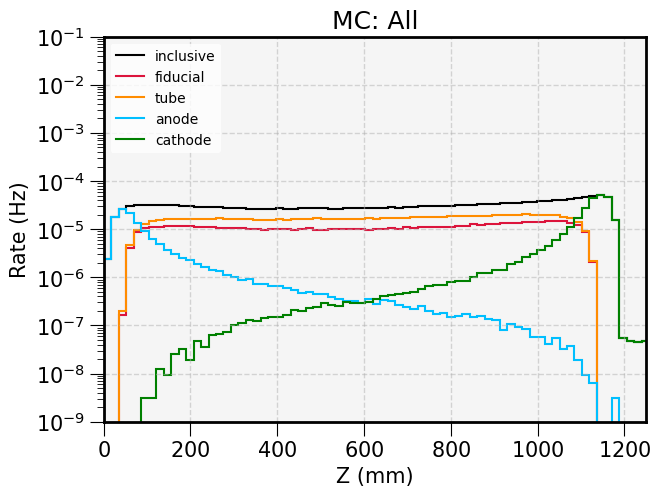

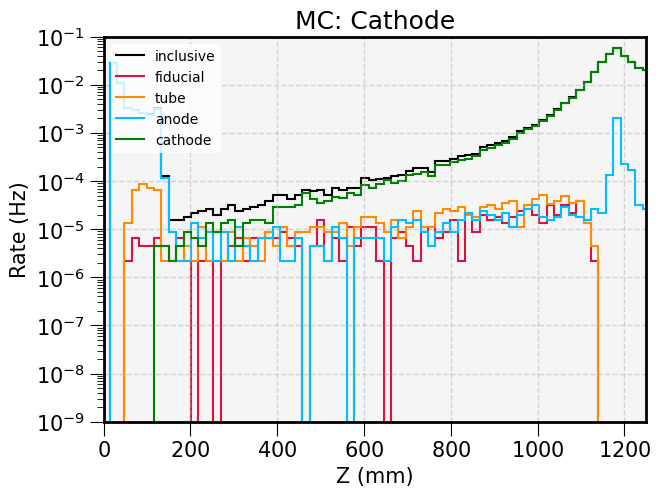

In [38]:
# Global
n_bins = 75
regions  = ['inclusive', 'fiducial', 'tube', 'anode', 'cathode']

for i, dataframe in enumerate([ALL_MC_EVT_DF, CATHODE_MC_EVT_DF]):

    plt.figure(figsize=(7, 5))
    plt.title(f'MC: {DETECTOR_ZONES[i]}')

    # Binning using "Inclusive" region
    _, Z_edges = np.histogram(dataframe['Z_bary'], bins=n_bins)

    for j, region in enumerate(regions):

        # Dataframe
        if region == 'inclusive':
            mc_region = dataframe.copy()
        else:
            mc_region = dataframe[dataframe['region'] == region].copy()

        # Variables
        Z = mc_region['Z_bary']

        # Histogram
        Z_counts, _ = np.histogram(Z, bins=Z_edges)
        Z_rate = Z_counts / (RUN_TIME_ALL if DETECTOR_ZONES[i] == 'All' else RUN_TIME_CATH)

        # ----- Plotting ----- #
        plt.stairs(Z_rate, Z_edges, label=region, 
                   fill=False, lw=1.5, ec=pt.hist_colors[j % len(pt.hist_colors)])
 
    # ----- Styling ----- #
    plt.xlabel('Z (mm)')
    plt.xlim(0, 1250)
    plt.ylabel('Rate (Hz)')
    plt.yscale('log')
    plt.ylim(1e-9, 1e-1)
    plt.legend(loc='upper left', fontsize=10)
    plt.title(f'MC: {DETECTOR_ZONES[i]}')
    plt.grid(True)
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

### $E$ Distribution
First, let's see the energy distribution for $^{214}Bi$-MC @ cathode

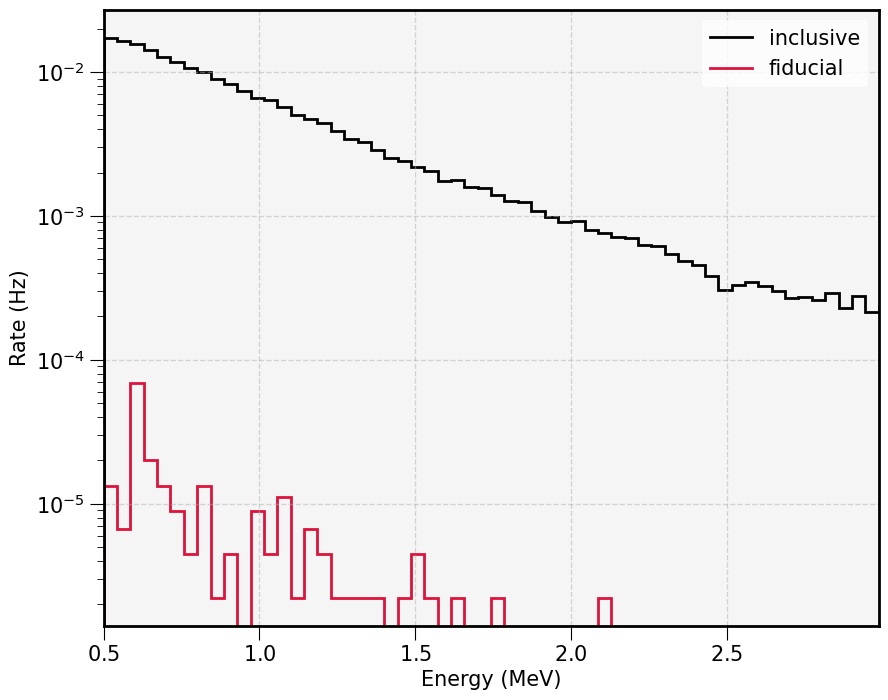

In [69]:
# Global
n_bins = 250
fig, ax = plt.subplots()

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, E_edges = np.histogram(CATHODE_MC_EVT_DF['E_mev'], bins=n_bins)

for i, region in enumerate(['inclusive', 'fiducial']):

    # Dataframe
    if region == 'inclusive':
        mc_df = CATHODE_MC_EVT_DF.copy()
    else:
        mc_df = FIDU_CATHODE_MC_EVT_DF.copy()

    # Variables
    E = mc_df['E_mev']

    # Histogram
    E_counts, _ = np.histogram(E, bins=E_edges)
    E_rate = E_counts / RUN_TIME_CATH

    # ----- Plotting ----- #
    plt.stairs(E_rate, E_edges, label=region, 
               fill=False, ec=pt.hist_colors[i % len(pt.hist_colors)], lw=2.0)
    
# plt.axvline(x=1.59, c='grey', ls='--', lw=1.0)        # DEP
    
# # ----- Styling ----- #
# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (2.8, 6e-3)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Energy (MeV)')
plt.xlim(TRG2_THRESHOLD, min(E_edges, key=lambda x: abs(x - 3)))
plt.ylabel('Rate (Hz)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Bi_Energy_Spectrum_Cathode_MC.pdf')
plt.show()

#### __Now _All-MC_, but normalized to cathode rates__

At the same time, we obtain the rate (from cathode MC) and the events (from all MC) in the ROI??? or maybe just ROI Rate re-escalated

In [48]:
Bi_MC_INFO

{'All': {'gen_cv': 2918945850,
  'incl_cv': 672414,
  'incl_roi_cv': 250,
  'fidu_cv': 162683,
  'fidu_roi_cv': 23},
 'Cathode': {'gen_cv': 385000,
  'incl_cv': 178023,
  'incl_roi_cv': 398,
  'fidu_cv': 98,
  'fidu_roi_cv': 0}}

In [95]:
ROI_INFO = {    
                'inclusive':{
                                'dataframe': pd.DataFrame(),
                                'rate_cv': 0,  'rate_err': 0
                },

                'fiducial': {
                                'dataframe': pd.DataFrame(),
                                'rate_cv': 0,  'rate_err': 0
                }
}

In [96]:
ROI_INFO

{'inclusive': {'dataframe': Empty DataFrame
  Columns: []
  Index: [],
  'rate_cv': 0,
  'rate_err': 0},
 'fiducial': {'dataframe': Empty DataFrame
  Columns: []
  Index: [],
  'rate_cv': 0,
  'rate_err': 0}}


--- Processing Region: INCLUSIVE ---

INCLUSIVE events: 672414
Scale factor from Cathode-MC = 0.264752 ± 0.000706
Scaled INCLUSIVE events: 178023.00
INCLUSIVE rate = 395.6375 mHz

--- ROI [2.4, 2.5] MeV Analysis for INCLUSIVE
  Unscaled events in ROI: 250
  Scaled events in ROI: 66.1880 ± 4.1898
  INCLUSIVE rate in ROI = (1.47e-04 ± 9.31e-06) Hz

--- Processing Region: FIDUCIAL ---

FIDUCIAL events: 162683
Scale factor from Cathode-MC = 0.000602 ± 0.000061
Scaled FIDUCIAL events: 98.00
FIDUCIAL rate = 0.2178 mHz

--- ROI [2.4, 2.5] MeV Analysis for FIDUCIAL
  Unscaled events in ROI: 23
  Scaled events in ROI: 0.0139 ± 0.0032
  FIDUCIAL rate in ROI = (3.08e-08 ± 7.13e-09) Hz

--- Processing Region: FIDUCIAL (BIPO) ---

FIDUCIAL (BIPO) events: 98
Scale factor from Cathode-MC = 1.000000 ± 1.414214
Scaled FIDUCIAL (BIPO) events: 98.00
FIDUCIAL (BIPO) rate = 0.2178 mHz


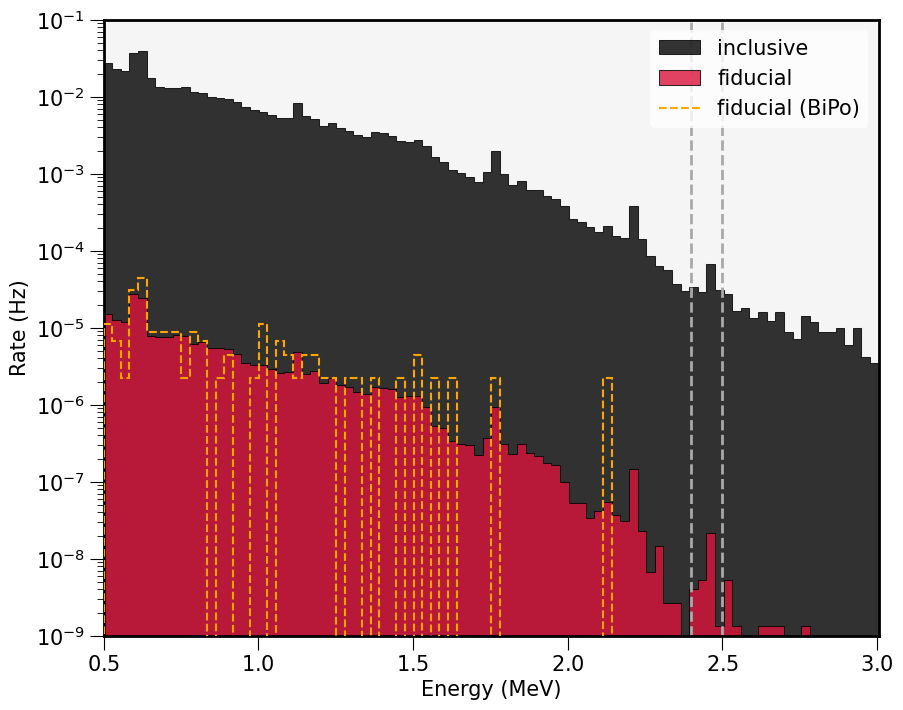

In [ ]:
# Global
n_bins = 250
fig, ax = plt.subplots(figsize=(10, 8))

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, E_edges = np.histogram(ALL_MC_EVT_DF['E_mev'], bins=n_bins)

for i, region in enumerate(['inclusive', 'fiducial', 'fiducial (BiPo)']):

    print(f"\n--- Processing Region: {region.upper()} ---")

    # Dataframe and cathode MC information
    if region == 'inclusive':
        mc_df = ALL_MC_EVT_DF.copy()
        evt_all_cv = Bi_MC_INFO['All']['incl_cv'];      evt_cathode_cv = Bi_MC_INFO['Cathode']['incl_cv']
    elif region == 'fiducial':
        mc_df = FIDU_ALL_MC_EVT_DF.copy()
        evt_all_cv = Bi_MC_INFO['All']['fidu_cv'];      evt_cathode_cv = Bi_MC_INFO['Cathode']['fidu_cv']
    else:   # 'fiducial (BiPo)'
        mc_df = FIDU_CATHODE_MC_EVT_DF.copy()
        evt_all_cv = 1.0;     evt_cathode_cv = 1.0      # There is no scaling in this case

    # Variables
    E = mc_df['E_mev']

    # ----- Normalized Histogram (by Cathode MC) ----- #
    E_counts, _ = np.histogram(E, bins=E_edges)
    print(f"\n{region.upper()} events: {E_counts.sum()}")
    # Computing the scale factor
    scale_factor_cv  = evt_cathode_cv / evt_all_cv
    scale_factor_err = scale_factor_cv * np.sqrt((1/evt_cathode_cv) + (1/evt_all_cv))           # Poisson errors, maybe wrong?
    print(f"Scale factor from Cathode-MC = {scale_factor_cv:.6f} ± {scale_factor_err:.6f}")
    # Scale the counts
    E_counts_scaled = E_counts * scale_factor_cv
    E_rate = E_counts_scaled / RUN_TIME_CATH                                                    # Important to use the MC time exposure of cathode sample
    print(f"Scaled {region.upper()} events: {E_counts_scaled.sum():.2f}")
    print(f"{region.upper()} rate = {E_rate.sum()*1e3:.4f} mHz")

    # ----- Extract ROI Rate  ----- #
    temp_df = pd.DataFrame()
    if (region == 'inclusive' or region == 'fiducial'):
        print(f"\n--- ROI [{ROI_MIN}, {ROI_MAX}] MeV Analysis for {region.upper()}")

        # ROI dataframe
        temp_df = mc_df[mc_df['E_mev'].between(ROI_MIN, ROI_MAX)].copy()    # Inclusive bounds
        ROI_INFO[region]['dataframe'] = temp_df

        # Events in ROI
        unscaled_counts_in_roi = temp_df['global_event'].nunique()
        print(f"  Unscaled events in ROI: {unscaled_counts_in_roi}")
        scaled_counts_in_roi_cv  = unscaled_counts_in_roi * scale_factor_cv
        scaled_counts_in_roi_err = scaled_counts_in_roi_cv * np.sqrt((1/unscaled_counts_in_roi) + (scale_factor_err/scale_factor_cv)**2)
        print(f"  Scaled events in ROI: {scaled_counts_in_roi_cv:.4f} ± {scaled_counts_in_roi_err:.4f}")
        # ROI Rate, careful with the error propagation!
        ROI_RATE_CV  = scaled_counts_in_roi_cv / RUN_TIME_CATH
        ROI_RATE_ERR = scaled_counts_in_roi_err / RUN_TIME_CATH
        print(f"  {region.upper()} rate in ROI = ({ROI_RATE_CV:.2e} ± {ROI_RATE_ERR:.2e}) Hz")
        ROI_INFO[region]['rate_cv'] = ROI_RATE_CV
        ROI_INFO[region]['rate_err'] = ROI_RATE_ERR

        # ----- Plotting ----- #
        plt.stairs(E_rate, E_edges, label=region, 
                    fill=True, color=pt.hist_colors[i % len(pt.hist_colors)], alpha=0.8,
                    ec='black', lw=0.75, zorder=i+1)
        
    else:
        # ----- Plotting ----- #
        plt.stairs(E_rate, E_edges, label=region, 
                    fill=False, ec='orange', lw=1.5, ls='--', zorder=i+1)
        
# # Important lines
# for x_peaks in [0.609, 1.120, 1.377, 1.764, 2.204, 2.447, 2.4, 2.5]:
#     plt.axvline(x=x_peaks, c='grey', ls='--', lw=1.0)

plt.axvline(x=ROI_MIN, c='darkgray', ls='--')        # ROI min
plt.axvline(x=ROI_MAX, c='darkgray', ls='--')        # ROI max
    
# # ----- Styling ----- #
# # Preliminary logo
# LOGO_BOX = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (2.35, 3e-3)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Energy (MeV)')
plt.xlim(TRG2_THRESHOLD, min(E_edges, key=lambda x: abs(x - 3)))
plt.ylabel('Rate (Hz)')
plt.ylim(1e-9, 1e-1)
plt.yscale('log')
plt.legend(loc='upper right', facecolor='white')
# plt.grid(True, zorder=-4)
plt.gca().set_facecolor("whitesmoke")
plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Rn_analysis/images/Bi_Energy_Spectrum.pdf')
plt.show()

## Background Indices

#### Helper functions & detector values

In [56]:
# ----- Fiducial Mass ----- #
volume_fid_CV, _ = pt.selection_volume(Z_UP - Z_LOW, 1, R_UP, 1)            # in mm3 - DO NOT USE THIS ERROR
volume_fid_CV /= 1e9                                                        # in m3
temp     = 293.15       # in [K]
pressure = 3.95         # in [bar]
R_gas    = 8.3145e-5    # in [m3·bar/(K·mol)]

# Use PV = nRT to calculate the number of moles
n_moles = (pressure * volume_fid_CV) / (R_gas * temp)    # in mol
print(f"Fiducial - number of moles = {n_moles:.4f} mol")
# Xenon molar mass
molar_mass_Xe = 135.9072    # in [g/mol]
MASS_FID_CV = n_moles * molar_mass_Xe / 1e3    # in [kg]
print(f"Fiducial - mass = {MASS_FID_CV:.4f} kg")

# ----- Background Index ----- #
def back_index(rate_hz: float, mass_kg: float, delta_e_mev: float) -> float:
    """
    Calculates the Background Index (BI).
    
    Parameters:
    - rate_hz: Rate in Hz.
    - mass_kg: Mass in kg.
    - delta_e_mev: Energy window in MeV.
    
    Returns:
    - BI in counts/(keV·kg·yr).
    """
    seconds_per_year = 31536000    # Number of seconds in a year
    rate_per_year = rate_hz * seconds_per_year
    delta_e_keV = delta_e_mev * 1e3
    bi = rate_per_year / (mass_kg * delta_e_keV)
    return bi

Fiducial - number of moles = 114.9668 mol
Fiducial - mass = 15.6248 kg


In [57]:
BACK_INDEX_ROI = back_index(ROI_RATE_CV, MASS_FID_CV, ROI_MAX - ROI_MIN)
print(f"Background Index in ROI: {BACK_INDEX_ROI:.2e} counts/(keV·kg·yr)")

Background Index in ROI: 6.21e-04 counts/(keV·kg·yr)


### Single-track

In [62]:
FIDU_CATHODE_MC_EVT_DF['n_cluster'].value_counts()

0    91
1     7
Name: n_cluster, dtype: int64

In [64]:
print(FIDU_ALL_MC_EVT_DF.global_event.nunique())
FIDU_ALL_MC_EVT_DF['n_cluster'].value_counts()

162683


0    146420
1     14384
2      1718
3       145
4        14
5         1
6         1
Name: n_cluster, dtype: int64

In [63]:
ROI_EVTS_DF['n_cluster'].value_counts()

0    13
1     5
3     3
2     2
Name: n_cluster, dtype: int64

In [67]:
# 0 means single-track events
single_track_eff = ROI_EVTS_DF['n_cluster'].value_counts(normalize=True).get(0, 0)
print(f"Single-track efficiency in ROI: {single_track_eff:.2%}")

BACK_INDEX_ROI_SINGLETRACK = BACK_INDEX_ROI * single_track_eff
print(f"Background Index in ROI after single-track cut: {BACK_INDEX_ROI_SINGLETRACK:.2e} counts/(keV·kg·yr)")

Single-track efficiency in ROI: 56.52%
Background Index in ROI after single-track cut: 3.51e-04 counts/(keV·kg·yr)
